---- steady state ----
  wall temps      : 157.3, 145.4 degC
  gas  400(+50) -> 323.7 degC to stack
  water 130 -> 140.0 -> 151.2 degC to drum
  Q_gas  = 5.037 MW
  Q_water= 5.023 MW


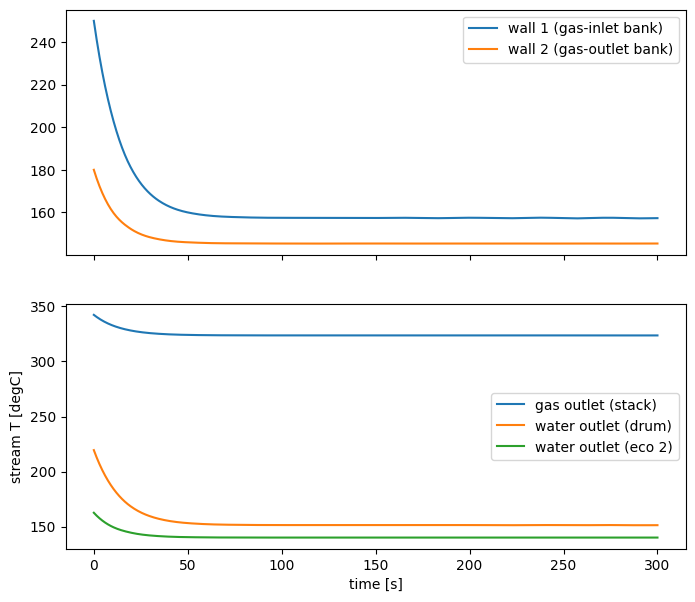

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Flue gas
T_flue_gas  = 400.0     # degC, gas inlet to bank 1
m_flue_gas  = 60.0      # kg/s
cp_flue_gas = 1100.0    # J/kg-K

# Feedwater
T_water_in  = 130.0     # degC, cold feedwater
m_water     = 55.0      # kg/s
cp_water    = 4300.0    # J/kg-K

# Metal (Wall)
rho_metal      = 7850.0  # kg/m^3 (carbon steel)
cp_metal       = 480.0   # J/kg-K
wall_thickness = 0.005   # m

# Heat transfer coefficients 
h_gas   = 100.0    # W/m^2-K 
h_water = 3000.0  # W/m^2-K 

# Calculates inside and outside area, and wall mass
def bank_geometry(n_tubes, D_o, L, t_wall):
    
    D_i     = D_o - 2.0 * t_wall
    A_gas   = np.pi * D_o * L * n_tubes                       # outer (gas) area
    A_water = np.pi * D_i * L * n_tubes                       # inner (water) area
    V_metal = n_tubes * (np.pi / 4.0) * (D_o**2 - D_i**2) * L 
    M_metal = rho_metal * V_metal
    return A_gas, A_water, M_metal

geom1 = bank_geometry(n_tubes=100, D_o=0.032, L=12.0, t_wall=wall_thickness)  # gas-inlet side
geom2 = bank_geometry(n_tubes=100, D_o=0.032, L=12.0, t_wall=wall_thickness)  # gas-outlet side


class Economiser:
    
    # Initialise
    def __init__(self, geom1, geom2):
        self.A_gas_1, self.A_water_1, self.M_metal_1 = geom1
        self.A_gas_2, self.A_water_2, self.M_metal_2 = geom2

    def gas_inlet(self, t):

        return T_flue_gas + (0.0 if t >= 100.0 else 0.0)

    @staticmethod
    def _side(T_in, T_wall, C, h, A):
       
        NTU = h * A / C
        eps = 1.0 - np.exp(-NTU)
        T_out = T_in - eps * (T_in - T_wall)      # = T_wall + (T_in-T_wall)e^-NTU
        Q = eps * C * (T_in - T_wall)
        return T_out, Q
    

    def solve(self, t, y):
        
        T_wall_1, T_wall_2 = y
        C_g = m_flue_gas * cp_flue_gas
        C_w = m_water * cp_water
        T_g_feed = self.gas_inlet(t)

        # Gas outlet temperatures
        T_g_out_1, Qg1 = self._side(T_g_feed,  T_wall_1, C_g, h_gas, self.A_gas_1)
        T_g_out_2, Qg2 = self._side(T_g_out_1, T_wall_2, C_g, h_gas, self.A_gas_2)

        # Water outlet temperatures
        T_w_out_2, Qw2 = self._side(T_water_in, T_wall_2, C_w, h_water, self.A_water_2)
        T_w_out_1, Qw1 = self._side(T_w_out_2,  T_wall_1, C_w, h_water, self.A_water_1)
    

        return dict(T_g_feed=T_g_feed, T_g_out_1=T_g_out_1, T_g_out_2=T_g_out_2,
                    T_w_out_2=T_w_out_2, T_w_out_1=T_w_out_1,
                    Qg1=Qg1, Qg2=Qg2, Qw1=Qw1, Qw2=Qw2)

    def ODEs(self, t, y):
        s = self.solve(t, y)
        dTwall_1 = (s['Qg1'] + s['Qw1']) / (self.M_metal_1 * cp_metal)
        dTwall_2 = (s['Qg2'] + s['Qw2']) / (self.M_metal_2 * cp_metal)
        return [dTwall_1, dTwall_2]


if __name__ == "__main__":
    eco = Economiser(geom1, geom2)

    y0    = [250.0, 180.0]          # initial wall guesses, degC
    t_end = 300.0
    sol   = solve_ivp(eco.ODEs, [0, t_end], y0, method='RK45', dense_output=True, t_eval=np.linspace(0, t_end, 600))

    # Reconstruct streams
    streams = [eco.solve(t, sol.y[:, i]) for i, t in enumerate(sol.t)]
    T_g_out = np.array([s['T_g_out_2'] for s in streams])   # gas to stack
    T_w_out_1 = np.array([s['T_w_out_1'] for s in streams])   # water to drum
    T_w_out_2 = np.array([s['T_w_out_2'] for s in streams])   # water leaving eco 2

    # Steady-state report + energy-balance check
    s = streams[-1]
    C_g, C_w = m_flue_gas * cp_flue_gas, m_water * cp_water
    Q_gas   = C_g * (s['T_g_feed'] - s['T_g_out_2'])
    Q_water = C_w * (s['T_w_out_1'] - T_water_in)
    print("---- steady state ----")
    print(f"  wall temps      : {sol.y[0,-1]:.1f}, {sol.y[1,-1]:.1f} degC")
    print(f"  gas  400 -> {s['T_g_out_2']:.1f} degC to stack")
    print(f"  water {T_water_in:.0f} -> {s['T_w_out_2']:.1f} -> {s['T_w_out_1']:.1f} degC to drum")
    print(f"  Q_gas  = {Q_gas/1e6:.3f} MW")
    print(f"  Q_water= {Q_water/1e6:.3f} MW")

    # Plotting

    fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    ax[0].plot(sol.t, sol.y[0], label='wall 1 (gas-inlet bank)')
    ax[0].plot(sol.t, sol.y[1], label='wall 2 (gas-outlet bank)')
    ax[0].legend()
    ax[1].plot(sol.t, T_g_out, label='gas outlet (stack)')
    ax[1].plot(sol.t, T_w_out_1, label='water outlet (drum)')
    ax[1].plot(sol.t, T_w_out_2, label='water outlet (eco 2)')
    ax[1].set_ylabel('stream T [degC]'); ax[1].set_xlabel('time [s]'); ax[1].legend()